In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s4e3/sample_submission.csv
/kaggle/input/playground-series-s4e3/train.csv
/kaggle/input/playground-series-s4e3/test.csv


✅ Data loaded successfully!
Train shape: (19219, 35), Test shape: (12814, 28)

🪪 ID column: id
🎯 Detected target columns (7): ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
✅ Number of features used: 27

✅ Preprocessing complete!


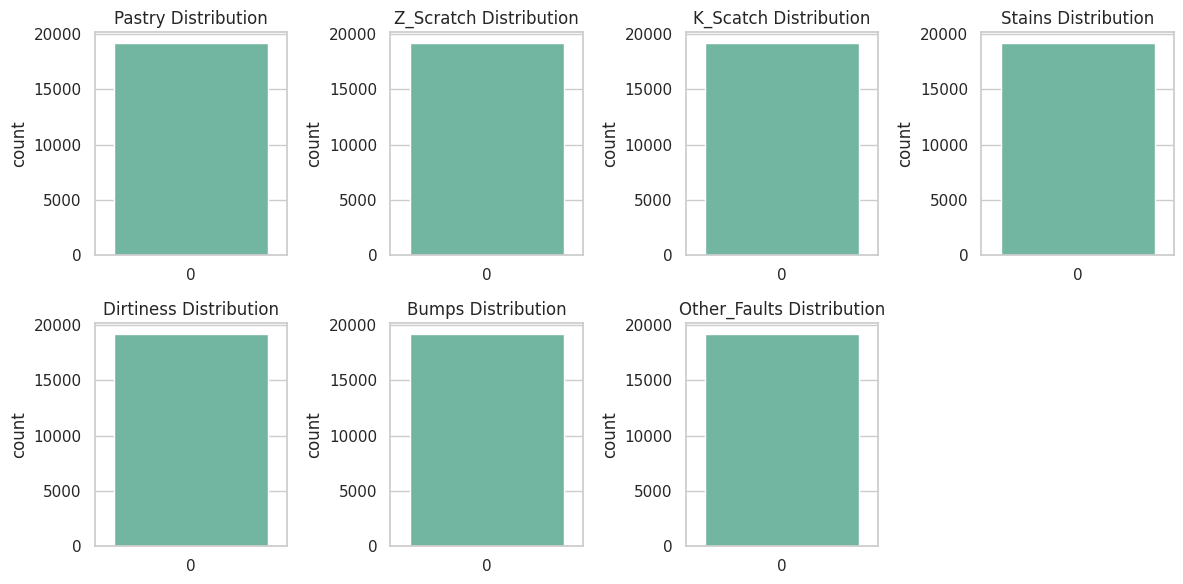

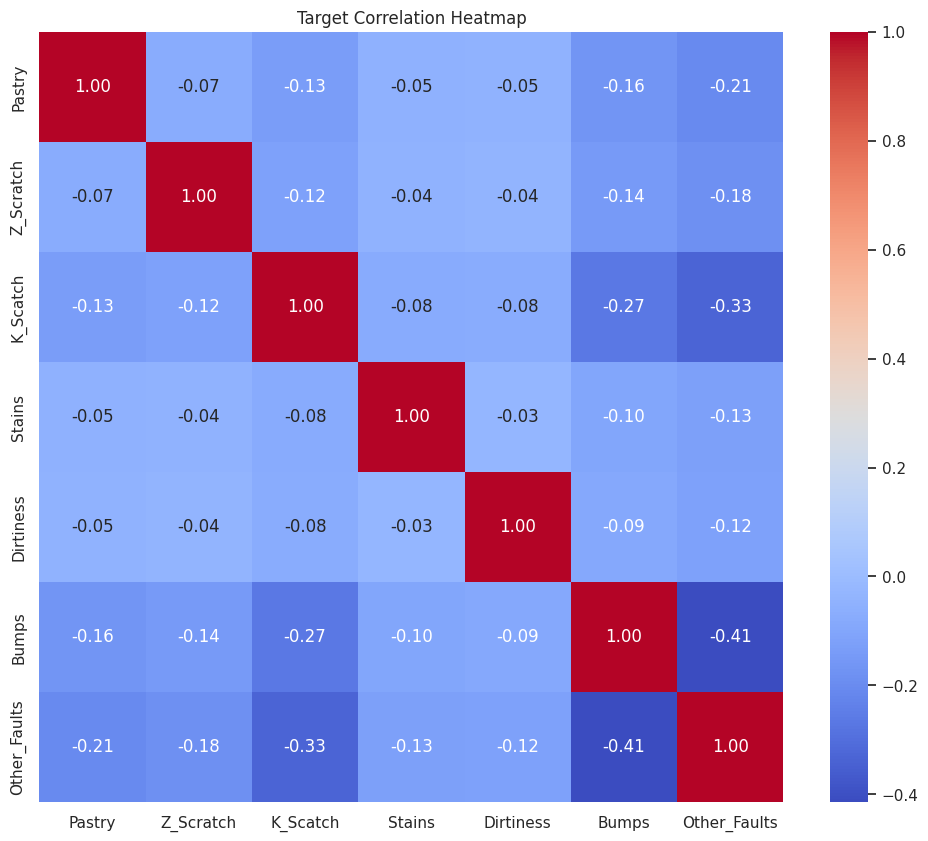


Training target [1/7]: Pastry
Training until validation scores don't improve for 100 rounds
[200]	train's auc: 0.959932	valid's auc: 0.87449
[400]	train's auc: 0.987294	valid's auc: 0.874633
Early stopping, best iteration is:
[310]	train's auc: 0.978428	valid's auc: 0.876341
Training until validation scores don't improve for 100 rounds
[200]	train's auc: 0.960345	valid's auc: 0.877027
Early stopping, best iteration is:
[272]	train's auc: 0.974781	valid's auc: 0.877739
Training until validation scores don't improve for 100 rounds
[200]	train's auc: 0.962785	valid's auc: 0.857271
[400]	train's auc: 0.989315	valid's auc: 0.857609
Early stopping, best iteration is:
[304]	train's auc: 0.979855	valid's auc: 0.858805
Training until validation scores don't improve for 100 rounds
[200]	train's auc: 0.960977	valid's auc: 0.869477
[400]	train's auc: 0.987179	valid's auc: 0.870143
Early stopping, best iteration is:
[376]	train's auc: 0.98512	valid's auc: 0.870594
Training until validation scores 

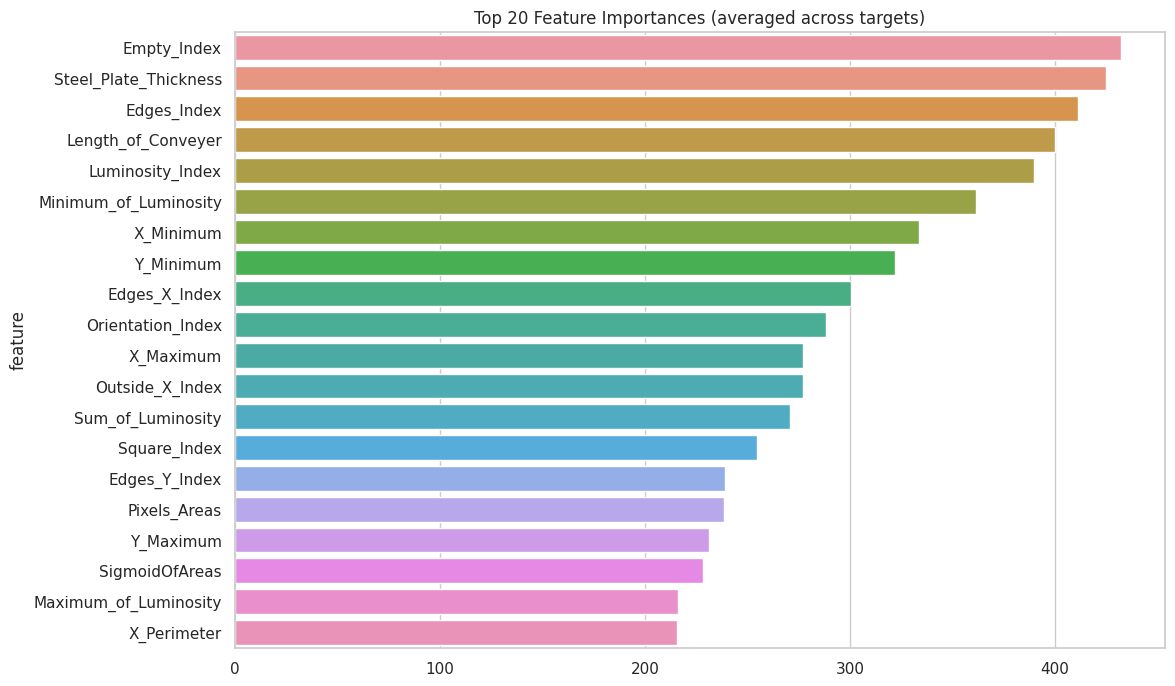


💾 Submission saved to /kaggle/working/submission.csv
      id    Pastry  Z_Scratch  K_Scatch    Stains  Dirtiness     Bumps  \
0  19219  0.496106   0.006394  0.030382  0.006695   0.018172  0.181288   
1  19220  0.259388   0.016357  0.038999  0.006698   0.154480  0.150134   
2  19221  0.001994   0.042744  0.065453  0.006785   0.005453  0.294479   
3  19222  0.191667   0.006657  0.028138  0.006800   0.008185  0.374416   
4  19223  0.002422   0.006731  0.028238  0.006851   0.007143  0.592793   

   Other_Faults  
0      0.331727  
1      0.321604  
2      0.480394  
3      0.415387  
4      0.395836  


In [2]:
# =============================================================
# 🧠 Steel Plate Defect Prediction with Graphs
# =============================================================

# === 1️⃣ Import Libraries ===
import numpy as np
import pandas as pd
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation

sns.set(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10,6)

# === 2️⃣ Load Dataset ===
DATA_DIR = "/kaggle/input/playground-series-s4e3"

train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

print("✅ Data loaded successfully!")
print(f"Train shape: {train.shape}, Test shape: {test.shape}")

# === 3️⃣ Identify ID and Target Columns ===
id_col = "id"
possible_targets = ["Pastry", "Z_Scratch", "K_Scatch", "K_Scratch", "Stains", "Dirtiness", "Bumps", "Other_Faults"]
target_cols = [c for c in possible_targets if c in train.columns]

print(f"\n🪪 ID column: {id_col}")
print(f"🎯 Detected target columns ({len(target_cols)}): {target_cols}")

# === 4️⃣ Define Features ===
feature_cols = [c for c in train.columns if c not in [id_col] + target_cols]
feature_cols = [c for c in feature_cols if c in test.columns]
print(f"✅ Number of features used: {len(feature_cols)}")

# === 5️⃣ Prepare Data ===
X = train[feature_cols].copy()
X_test = test[feature_cols].copy()
y = train[target_cols].copy()

# Handle missing values
for df in [X, X_test]:
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].fillna("Missing").astype(str)
            df[col] = pd.factorize(df[col])[0]
        else:
            df[col] = df[col].fillna(df[col].median())

print("\n✅ Preprocessing complete!")

# === 6️⃣ Visualize Target Distributions ===
plt.figure(figsize=(12,6))
for i, target in enumerate(target_cols, 1):
    plt.subplot(2, 4, i)
    sns.countplot(y[target])
    plt.title(f"{target} Distribution")
plt.tight_layout()
plt.show()

# === 7️⃣ Correlation Heatmap ===
plt.figure(figsize=(12,10))
corr = train[target_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Target Correlation Heatmap")
plt.show()

# === 8️⃣ LightGBM Parameters ===
lgb_params = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "metric": "auc",
    "learning_rate": 0.02,
    "num_leaves": 31,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 4,
    "seed": 42,
    "verbose": -1,
    "n_jobs": -1,
}

# === 9️⃣ Cross-Validation Setup ===
N_FOLDS = 5
kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
X_values = X.values
X_test_values = X_test.values

oof = np.zeros((len(X), len(target_cols)))
preds_test = np.zeros((len(X_test), len(target_cols)))
scores = []
feature_importances = pd.DataFrame()

# === 🔟 Model Training Loop ===
for tidx, target in enumerate(target_cols):
    print(f"\n==============================")
    print(f"Training target [{tidx+1}/{len(target_cols)}]: {target}")
    print("==============================")

    y_col = y[target].values

    if np.isnan(y_col).all() or len(np.unique(y_col[~np.isnan(y_col)])) == 1:
        print(f"Skipping {target}")
        continue

    fold_scores = []
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_values, y_col), 1):
        X_tr, X_val = X_values[tr_idx], X_values[val_idx]
        y_tr, y_val = y_col[tr_idx], y_col[val_idx]

        ltrain = lgb.Dataset(X_tr, label=y_tr)
        lvalid = lgb.Dataset(X_val, label=y_val, reference=ltrain)

        clf = lgb.train(
            params=lgb_params,
            train_set=ltrain,
            valid_sets=[ltrain, lvalid],
            valid_names=["train", "valid"],
            num_boost_round=5000,
            callbacks=[
                early_stopping(stopping_rounds=100),
                log_evaluation(period=200)
            ]
        )

        oof[val_idx, tidx] = clf.predict(X_val, num_iteration=clf.best_iteration)
        preds_test[:, tidx] += clf.predict(X_test_values, num_iteration=clf.best_iteration) / N_FOLDS
        fold_scores.append(roc_auc_score(y_val, oof[val_idx, tidx]))

        # Collect feature importances
        fold_importance = pd.DataFrame()
        fold_importance["feature"] = feature_cols
        fold_importance["importance"] = clf.feature_importance()
        fold_importance["fold"] = fold
        fold_importance["target"] = target
        feature_importances = pd.concat([feature_importances, fold_importance], axis=0)

        del clf, ltrain, lvalid
        gc.collect()

    mean_auc = np.mean(fold_scores)
    scores.append(mean_auc)
    print(f"✅ Target {target} mean CV AUC: {mean_auc:.6f}")

# === 1️⃣1️⃣ Overall Performance ===
print("\n==============================")
print(f"Average CV AUC across all targets: {np.mean(scores):.6f}")
print("==============================")

# === 1️⃣2️⃣ Feature Importance Plot ===
plt.figure(figsize=(12,8))
imp_mean = feature_importances.groupby("feature")["importance"].mean().sort_values(ascending=False).head(20)
sns.barplot(x=imp_mean.values, y=imp_mean.index)
plt.title("Top 20 Feature Importances (averaged across targets)")
plt.show()

# === 1️⃣3️⃣ Submission ===
sub = sample_sub.copy()
for col in target_cols:
    if col in sub.columns:
        sub[col] = preds_test[:, target_cols.index(col)]
sub.to_csv("/kaggle/working/submission.csv", index=False)
print("\n💾 Submission saved to /kaggle/working/submission.csv")
print(sub.head())
